# Ejercicios de Seaborn

# 1. Importa pandas, pyplot y seaborn

In [19]:
import pandas as pd 
import seaborn as sns
import plotly as py

# plotly
# import plotly.plotly as py
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)
import plotly.graph_objs as go

# word cloud library
from wordcloud import WordCloud

# matplotlib
import matplotlib.pyplot as plt
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("./data"))

# Any results you write to the current directory are saved as output.

import warnings
warnings.filterwarnings("ignore")

['Pokemon.csv']


# 3. Lee 'Pokemon.csv', lee la primera columna del csv como índice del DataFrame

In [20]:
pokemon = pd.read_csv('./data/Pokemon.csv', index_col=0) # Ruta lógica desde donde se encuentra el dataset

In [53]:
pokemon

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
147,Dratini,Dragon,NaN,300,41,64,45,50,50,50,1,False
148,Dragonair,Dragon,NaN,420,61,84,65,70,70,70,2,False
149,Dragonite,Dragon,Flying,600,91,134,95,100,100,80,3,False


# 4. Mira las primeras filas del dataset para hacerte una idea de los datos cargados

In [21]:
pokemon.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


# 5. Haz un scatter plot con lmplot(), que es el método que pinta una regresión lineal
### Pasa el DataFrame como argumento del método en el parámetro llamado data

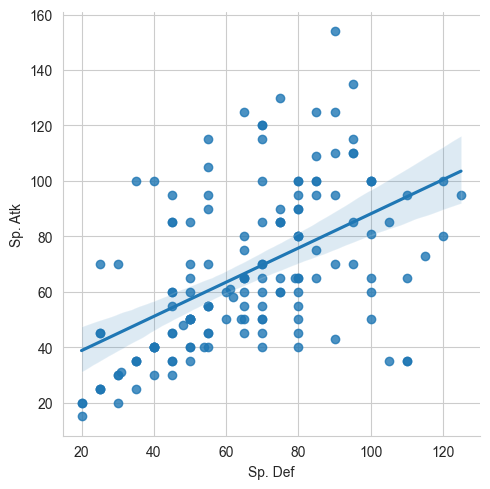

In [22]:
# Comparamos el total con el ataque
sns.lmplot(data=pokemon,x='Sp. Def',y='Sp. Atk');

# 6. No queremos ver la línea recta de la regresión lineal.
### prueba a añadir fit_reg a falso

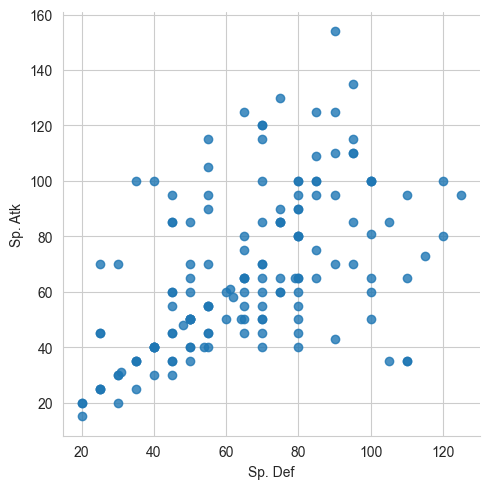

In [23]:
sns.lmplot(data=pokemon,x='Sp. Def',y='Sp. Atk',fit_reg=False);

# 7. Vamos a decir qué variable (columna del DataFrame) codifica los colores (hue)
### Que el hue sea el Stage

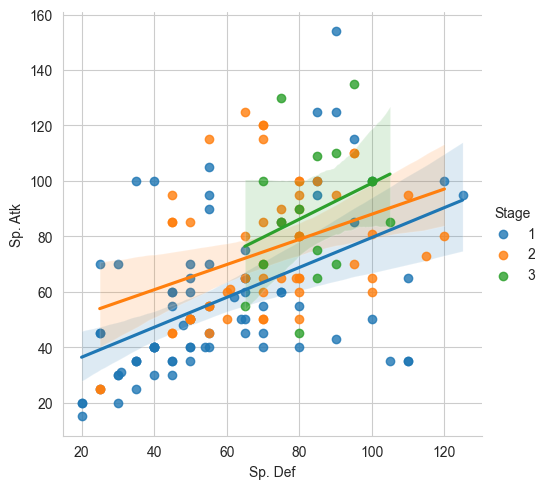

In [24]:
sns.lmplot(data=pokemon,x='Sp. Def',y='Sp. Atk',hue='Stage');

# 8. Limita el eje x entre 20 y 100

(20.0, 100.0)

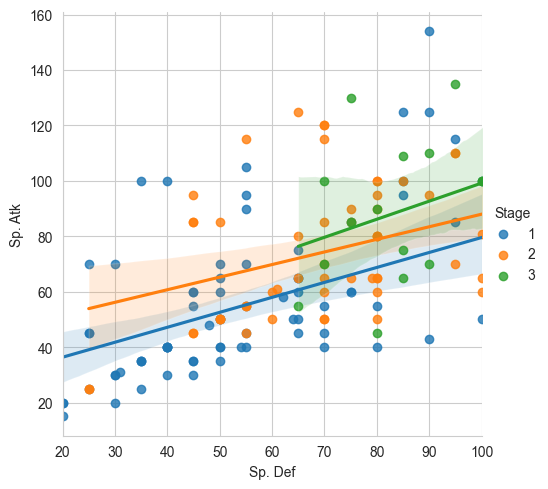

In [25]:
sns.lmplot(data=pokemon,x='Sp. Def',y='Sp. Atk',hue='Stage');

plt.xlim(20,100)

# 9. Dibuja un diagrama de cajas con el dataframe

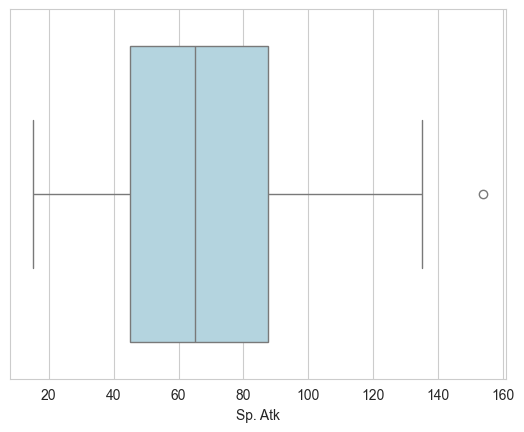

In [26]:
sns.boxplot(x=pokemon["Sp. Atk"], color="lightblue");

# 10. No nos interesan las columnas Total, Stage ni Legendary
### Bórralos del DataFrame y vuelve a dibujar el diagrama de cajas

In [27]:
pokemon2 = pokemon.drop(columns=['Total','Stage','Legendary'])
pokemon2

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45
2,Ivysaur,Grass,Poison,60,62,63,80,80,60
3,Venusaur,Grass,Poison,80,82,83,100,100,80
4,Charmander,Fire,NaN,39,52,43,60,50,65
5,Charmeleon,Fire,NaN,58,64,58,80,65,80
...,...,...,...,...,...,...,...,...,...
147,Dratini,Dragon,NaN,41,64,45,50,50,50
148,Dragonair,Dragon,NaN,61,84,65,70,70,70
149,Dragonite,Dragon,Flying,91,134,95,100,100,80


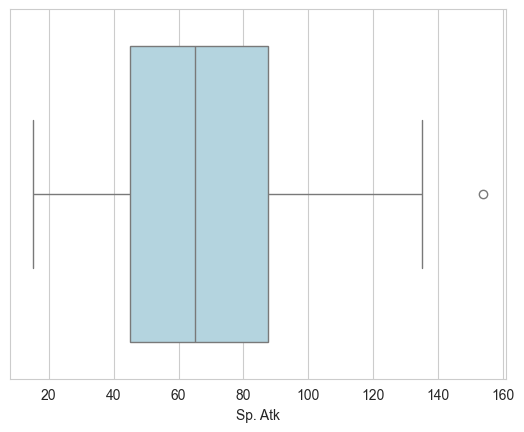

In [28]:
sns.boxplot(x=pokemon2["Sp. Atk"], color="lightblue");

# 11. Mira cuántos 'Type 1' diferentes hay en el DataFrame

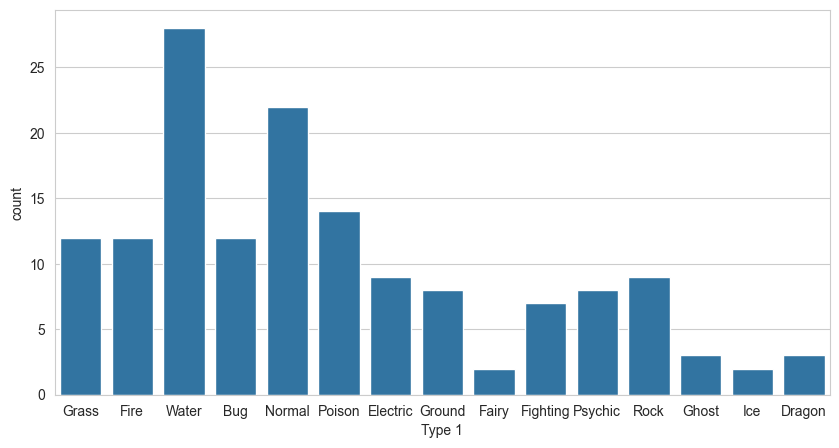

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(data=pokemon2, x='Type 1');


# 12. Quédate del Dataframe solo con los 'Type 1' iguales a 'Grass', 'Fire' o 'Water'

<Axes: xlabel='Type 1', ylabel='count'>

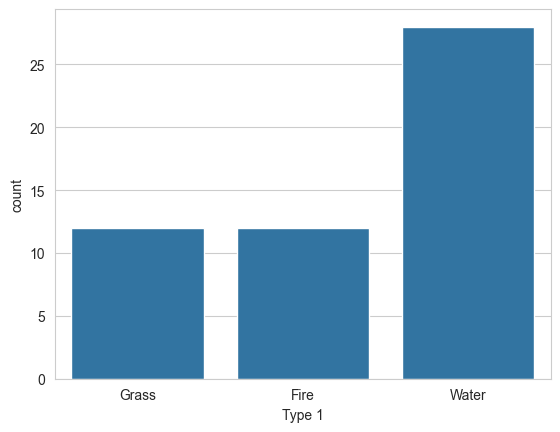

In [30]:
tipos = ['Grass', 'Fire', 'Water']
df_gfw = pokemon2[pokemon2['Type 1'].isin(tipos)]

sns.countplot(data=df_gfw, x='Type 1')


# 13. Usa un estilo 'whitegrid'

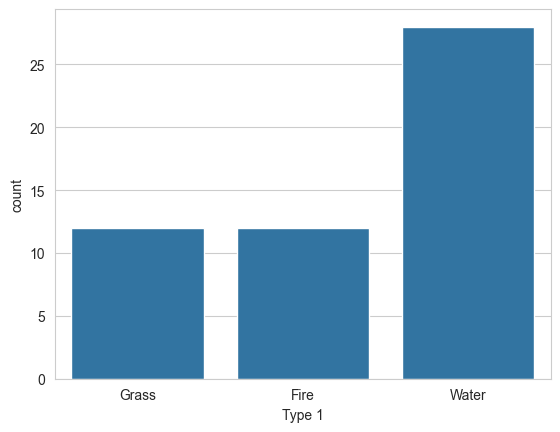

In [31]:
sns.set_style("whitegrid")

sns.countplot(data=df_gfw, x='Type 1');

# 14. Pinta diagramas de violín con el DataFrame filtrado por los 3 tipos

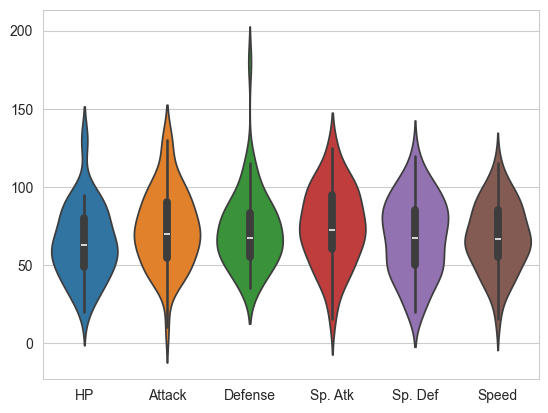

In [33]:
# Usamos el df filtrado y representamos el violín
sns.violinplot(data=df_gfw);

# 15. Escribe una lista de colores con valores '#78C850', '#F08030',  '#6890F0'

In [34]:
colors=['#78C850', '#F08030',  '#6890F0']
colors

['#78C850', '#F08030', '#6890F0']

# 16. Pinta de nuevo los diagramas de violín añadiendo esos colores en la paleta (palette)

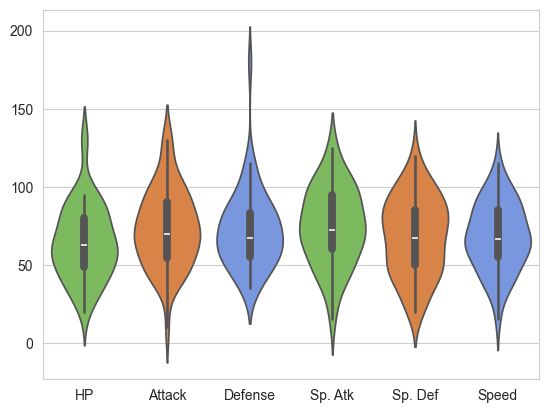

In [35]:
sns.violinplot(data=df_gfw, palette=colors);

# 17. Con el diagrama de violín vemos la forma de la distribución, pero no sabemos si Grass tiene muchos puntos y Fire tiene muy pocos.
### Para ver esto, usamos el swarmplot.
### Pinta el último diagrama de violines pero con un swarmplot en lugar de un violin

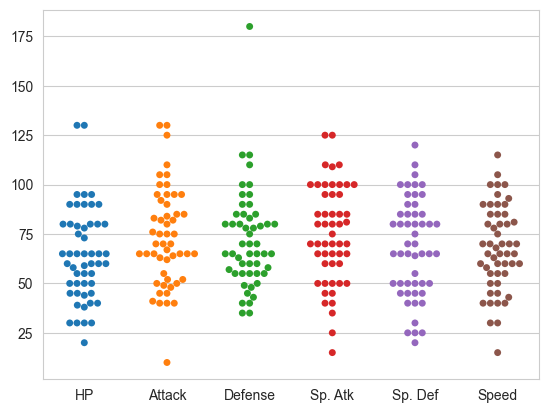

In [36]:
sns.swarmplot(data=df_gfw);
# No se visualiza por tipo de pokemon

# 18. Queremos ver los violines a la vez que los swarm, los podemos pintar juntos. 
### Elimina los diagramas de caja dentro de los violines con el parámetro inner = None y pon una transparencia de 0.9 en el swarmplot
### Pon un título con pyplot (como siempre)

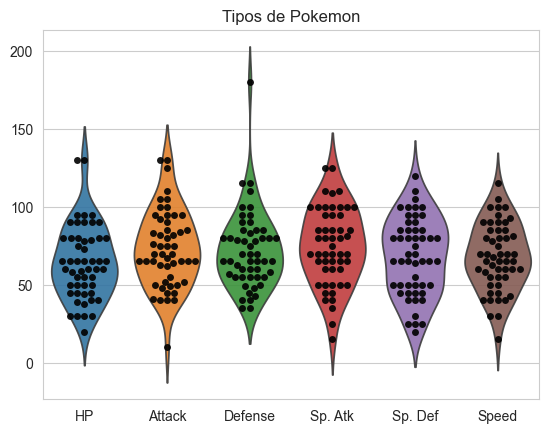

In [37]:
sns.violinplot(data=df_gfw, inner=None)

# He visto que, al parecer, no se le puede 
ax = sns.swarmplot(data=df_gfw, color='black', alpha=0.9)

for c in ax.collections:
    c.set_alpha(0.9)

# Ponemos título
plt.title("Tipos de Pokemon");

# 19. Veamos la función melt() de pandas. Melt toma los valores de varias columnas y los junta todos en una misma columna nueva.
### Dado un DataFrame, melt recibe varios parámetros:
### * qué columnas del DataFrame se quedan igual
### * qué nombres de columnas del dataframe pasan a ser una columna nueva
### * cómo queremos llamar esas nuevas columnas

### Primero recuerda el Dataframe df_grass_fire_water con las primeras 5 filas

In [38]:
df_gfw.head()

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45
2,Ivysaur,Grass,Poison,60,62,63,80,80,60
3,Venusaur,Grass,Poison,80,82,83,100,100,80
4,Charmander,Fire,NaN,39,52,43,60,50,65
5,Charmeleon,Fire,NaN,58,64,58,80,65,80


# 20. Queremos dejar igual las variables 'Name' y 'Type 1'
### Queremos añadir una columa nueva cuyos valores sean las columnas que queremos apilar y que se llame 'New Column'
### Escribimos df_gfw.melt(id_vars=['Name', 'Type 1'], value_vars=[...], var_name='New Column')

In [39]:
# Me quedo solamente con los datos numéricos, quitamos 'Type 2'
df_melted = df_gfw.melt(id_vars=['Name', 'Type 1'], value_vars=['HP','Attack','Defense','Sp. Atk', 'Sp. Def', 'Speed'], var_name='New Column')
df_melted

,Name,Type 1,New Column,value
0,Bulbasaur,Grass,HP,45
1,Ivysaur,Grass,HP,60
2,Venusaur,Grass,HP,80
3,Charmander,Fire,HP,39
4,Charmeleon,Fire,HP,58
...,...,...,...,...
307,Gyarados,Water,Speed,81
308,Lapras,Water,Speed,60
309,Vaporeon,Water,Speed,65
310,Flareon,Fire,Speed,65


# 21. Pintamos el swarmplot con el melted y entendemos la información

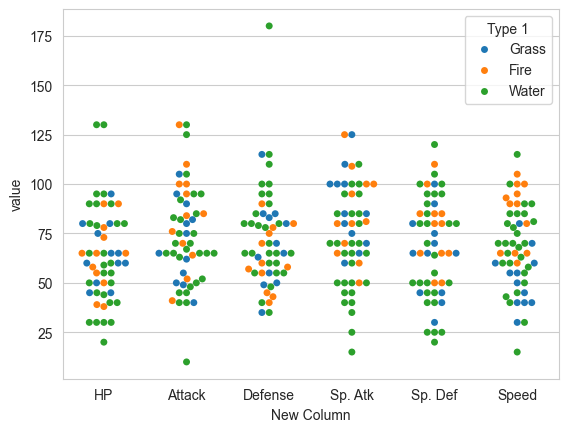

In [40]:
sns.swarmplot(data=df_melted,
              x='New Column',
              y='value',
              hue='Type 1');

# Visualizamos la distribución para las estadísticas numéricas
# Considero que hay bastante dispersión, aunque debemos tener en cuenta que estamos mezclando 
# diferentes estados de evolución (donde las evoluciones suelen tienen mejores estadísticas)
# Si separáramos por estados de evolución, seguramente se vería mucho mejor si esta hipótesis se cumple
# Hay unos pocos outliers, podría consistir en algún pokemon tanque o legendario donde las estadísticas son mejores
# o podrían pokemon inútiles que tienen carencias muy marcadas. Por ejemplo, Magikarp con muy poco ataque y ataque especial,
# Cloyster con mucha defensa o Slowpoke siendo uno de los pokemon más lentos...

# 22. Basándote en el gráfico anterior, define el tamaño de la figura en (10,6) (usa plt)
### En el swarmplot añade el argumento dodge a True y usa la anterior paleta de colores Pokemon

### Dodge en inglés es "esquivar", ¿qué diferencia ves?

## Usando plt 
### fija el límite del eje Y entre 0 y 200
### fija la leyenda con bbox_to_anchor en upper left. Pista: upper left es el código 2 y se usa el parámetro loc.

### Observa que incluso usando Seaborn, usamos Pyplot para trabajar con los ejes, la leyenda y el tamaño
### Lo importante es que Seaborn y Pyplot conviven bien juntos

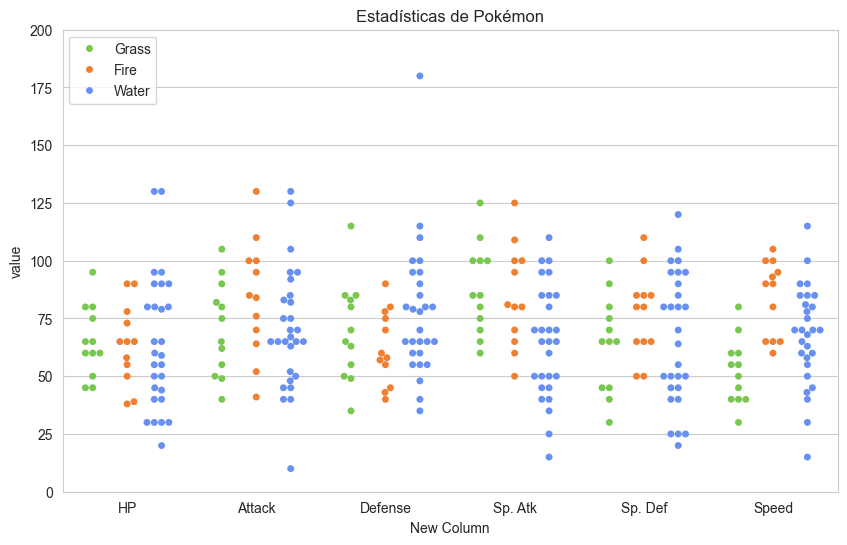

In [41]:
plt.figure(figsize=(10, 6))

sns.swarmplot(data=df_melted,
              x='New Column',
              y='value',
              hue='Type 1',
              dodge=True,
              palette=colors);

plt.ylim(0,200)

plt.title('Estadísticas de Pokémon')
plt.legend(loc=2, bbox_to_anchor=(0, 1))

# Al añadirle dodge, se separan los puntos por tipo. 

# 23. Mapas de calor
### Calcula las correlaciones del primer DataFrame original df
### Pista: las correlaciones se calculan con el método corr()
### Recuerda: las correlaciones miden entre dos variables, si varío una, cuánto me varía la otra (cómo están de relacionadas)

In [42]:
# Creamos un df con los valores de correlación de variables numéricas
poke_corr = pokemon2.select_dtypes(include='number').corr().abs().round(2)
poke_corr

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
HP,1.00,0.31,0.12,0.24,0.49,0.04
Attack,0.31,1.00,0.49,0.15,0.37,0.19
Defense,0.12,0.49,1.00,0.19,0.14,0.05
Sp. Atk,0.24,0.15,0.19,1.00,0.52,0.41
Sp. Def,0.49,0.37,0.14,0.52,1.00,0.39
Speed,0.04,0.19,0.05,0.41,0.39,1.00


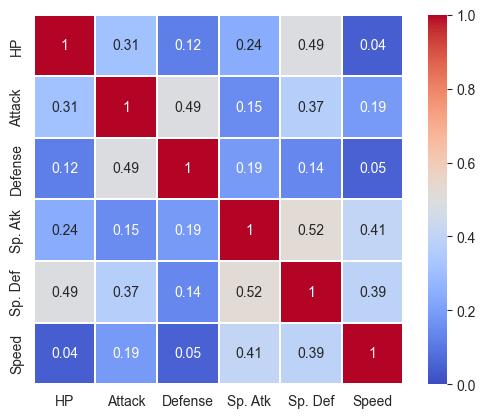

In [43]:
sns.heatmap(poke_corr,
            vmin=0,
            vmax=1,
            cmap='coolwarm',
            square=True,
            linewidths=.1,
            annot=True);

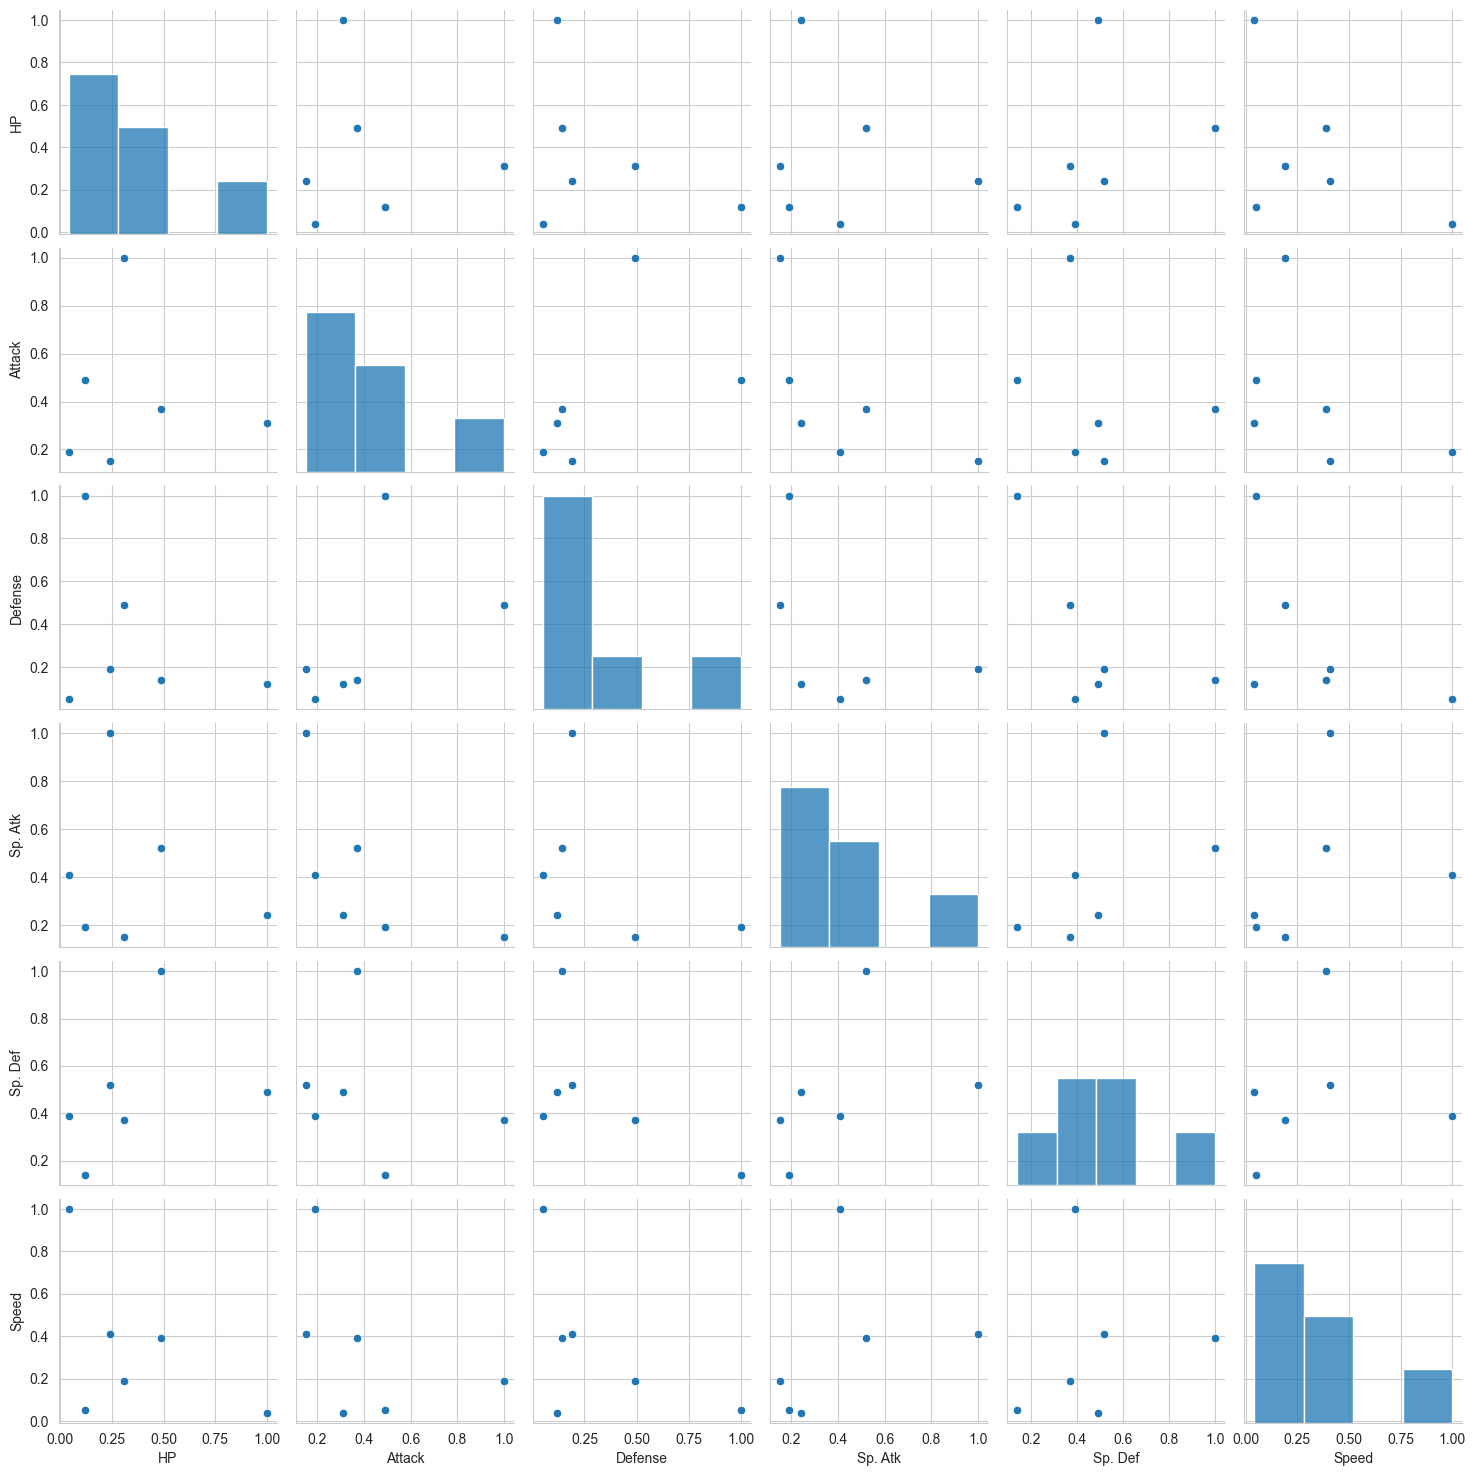

In [44]:
# Pruebo con los gráficos de pares
sns.pairplot(poke_corr);
# pero tampoco muestra nada claro

### ¿la correlación entre qué valores se encuentra?
### la autocorrelación es la correlación de una variable consigo misma, ¿qué aprecias?
### Encuentra dos variables que veas que están fuertemente relacionadas según la correlación

No encuentro ninguna correlación fuerte entre ninguna variable.  
Las únicas que podrían correlacionarse son ata esp-def esp (0.52), ataque-defensa(0.49) y HP-def esp(0.49).

# 24. Pinta el histograma y la densidad de probabilidad del nivel de defensa usando el DataFrame original

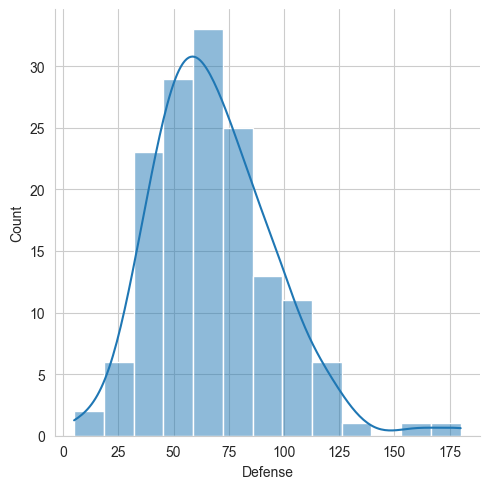

In [50]:
sns.displot(pokemon2["Defense"],
            kind="hist",
            bins=13,
            kde=True);

para hacer 2 ejes Y, y ver el porcentaje de densidad de probabilidad (KDE)

Text(0.5, 1.0, 'Histograma + KDE con doble eje Y')

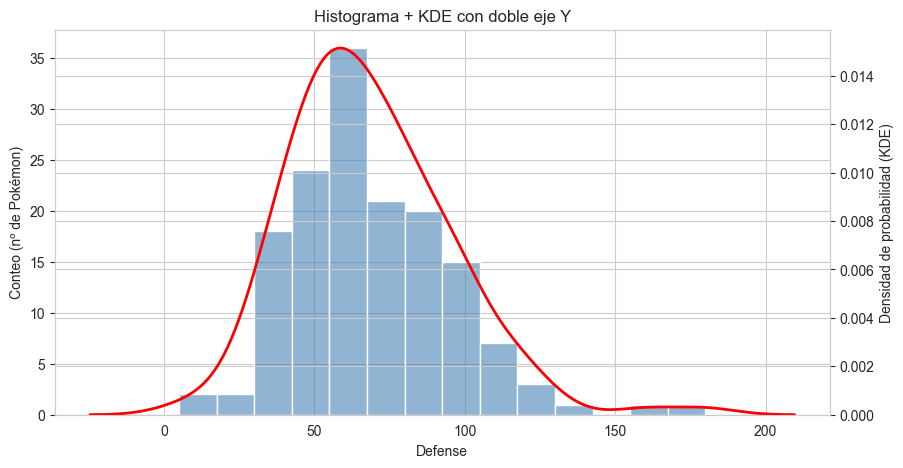

In [52]:
# Creamos la figura con la interfaz OO porque necesitamos controlar dos ejes
fig, ax1 = plt.subplots(figsize=(10, 5))

# En el eje izquierdo (ax1): el histograma con conteo normal
# kde=False porque vamos a dibujar el KDE aparte en el otro eje
sns.histplot(pokemon["Defense"], kde=False, ax=ax1, color="steelblue", alpha=0.6)
ax1.set_ylabel("Conteo (nº de Pokémon)")

# Creamos un segundo eje Y a la derecha que comparte el mismo eje X
# twinx() = "twin x" = "gemelo en X" = mismo eje X, distinto eje Y
ax2 = ax1.twinx()

# En el eje derecho (ax2): la curva KDE con su escala de densidad real
sns.kdeplot(pokemon["Defense"], ax=ax2, color="red", linewidth=2)
ax2.set_ylabel("Densidad de probabilidad (KDE)")

ax1.set_xlabel("Defense")
ax1.set_title("Histograma + KDE con doble eje Y")

# 25. Pinta un diagrama de barras de la columna 'Type 1' usando el DataFrame original
### Usa un sns.countplot
### Usa plt.xticks y gira las etiquetas

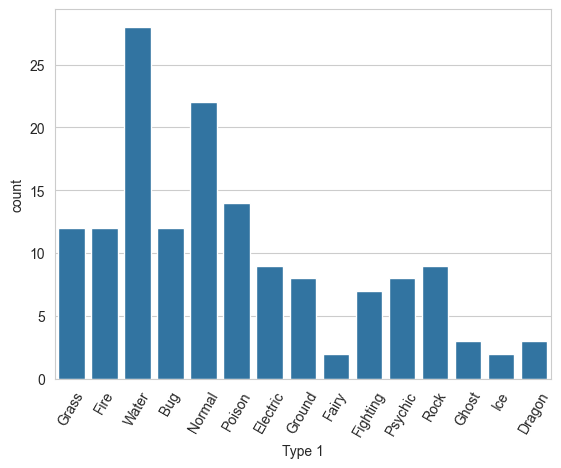

In [46]:
sns.countplot(data = pokemon2, x = pokemon2["Type 1"])
plt.xticks(rotation=60);

# 26. Usa catplot con el DataFrame original.
### Muestra el valor de Defense según el 'Type 1', muestra un subplot para legendarios y otro para no legendarios y divide los colores según el Type 2

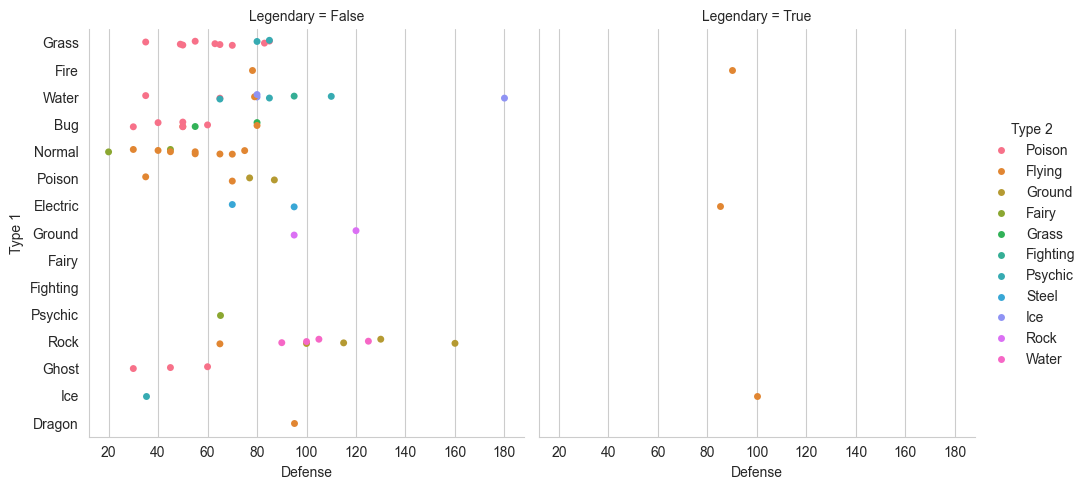

In [47]:
sns.catplot(data = pokemon, x = 'Defense', y = 'Type 1', col = 'Legendary', hue = 'Type 2');


# 27. Muestra una función distribución de probabilidad con kdeplot (curvas de nivel) de la defensa respecto al ataque.
### Di un bin 2D donde caigan muchos puntos (ataque, defensa).

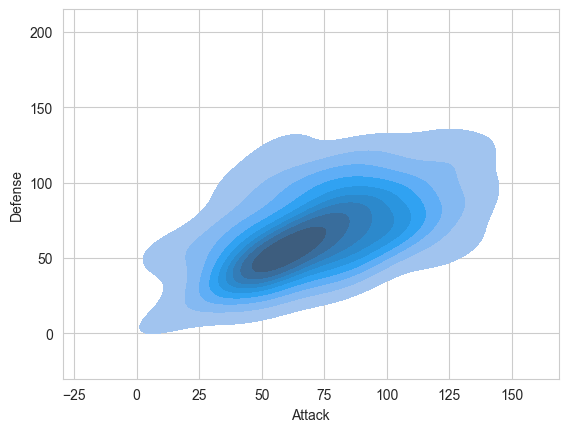

In [54]:
sns.kdeplot(data = pokemon, x = 'Attack', y = 'Defense', fill=True);


# 28. Pinta una distribución de probabilidad conjunta con jointplot, pintando la defensa respecto al ataque del DataFrame original

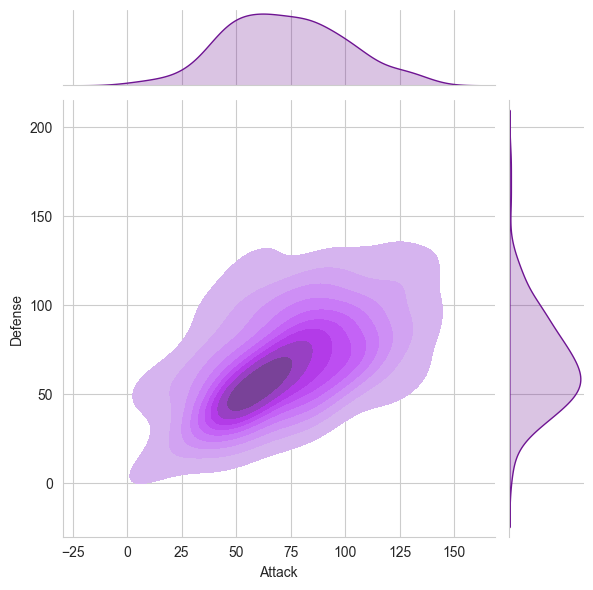

In [56]:
sns.jointplot(data=pokemon,
              x='Attack',
              y='Defense',
              kind="kde",
              color="#6E1492",
              fill=True);